In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

In [2]:
# Standard library imports
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

# Third-party scientific computing
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# Machine learning
from sklearn.pipeline import Pipeline

# Local imports - data processing
from src.data_models.caravanify import Caravanify, CaravanifyConfig
from src.data_models.datamodule import HydroDataModule
from src.preprocessing.grouped import GroupedTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer
from src.preprocessing.log_scale import LogTransformer

# Local imports - models
from src.models.dummy import RepeatLastValuesConfig, LitRepeatLastValues
from src.models.tft import TFTConfig, LitTFT
from src.models.ealstm import EALSTMConfig, LitEALSTM
from src.models.tide import TiDEConfig, LitTiDE
from src.models.tsmixer import TSMixerConfig, LitTSMixer

# Local imports - evaluation
from src.model_evaluation.evaluators import TSForecastEvaluator
from src.model_evaluation.hp_from_yaml import hp_from_yaml

---

In [ ]:
STATIC_FEATURES = [
    "gauge_id",
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

FORCING_FEATURES = [
    "snow_depth_water_equivalent_mean",
    "surface_net_solar_radiation_mean",
    "surface_net_thermal_radiation_mean",
    "potential_evaporation_sum_ERA5_LAND",
    "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "total_precipitation_sum",
]

TARGET = "streamflow"

In [4]:
# Either Kyrgyzstan or Tajikistan or combined
COUNTRY = "Kyrgyzstan"

In [5]:
ealstm_yaml = f"/Users/cooper/Desktop/CAMELS-CH/experiments/SimilarityBasedTransfer/yaml_files/{COUNTRY.lower()}/ealstm.yaml"
tft_yaml = f"/Users/cooper/Desktop/CAMELS-CH/experiments/SimilarityBasedTransfer/yaml_files/{COUNTRY.lower()}/tft.yaml"
tide_yaml = f"/Users/cooper/Desktop/CAMELS-CH/experiments/SimilarityBasedTransfer/yaml_files/{COUNTRY.lower()}/tide.yaml"
tsmixer_yaml = f"/Users/cooper/Desktop/CAMELS-CH/experiments/SimilarityBasedTransfer/yaml_files/{COUNTRY.lower()}/tsmixer.yaml"


tft_hp = hp_from_yaml("tft", tft_yaml)
tide_hp = hp_from_yaml("tide", tide_yaml)
ealstm_hp = hp_from_yaml("ealstm", ealstm_yaml)
tsmixer_hp = hp_from_yaml("tsmixer", tsmixer_yaml)

In [6]:
TFT_config = TFTConfig(**tft_hp)
EALSTM_config = EALSTMConfig(**ealstm_hp)
TiDE_config = TiDEConfig(**tide_hp)
TSMixer_config = TSMixerConfig(**tsmixer_hp)

dummy_config = RepeatLastValuesConfig(
    input_len=tide_hp["input_len"],
    input_size=tide_hp["input_size"],
    output_len=tide_hp["output_len"],
)

---

In [ ]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    # human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

ca_caravan = Caravanify(config)
ca_basins = ca_caravan.get_all_gauge_ids()
# ca_basins = [bid for bid in ca_basins if bid not in ["CA_17110", "CA_17329"]]

print(f"Found {len(ca_basins)} total CA basins")

ca_caravan.load_stations(ca_basins)

# Prepare data frames
ts_columns = FORCING_FEATURES + [TARGET]
static_columns = STATIC_FEATURES

ca_ts_data = ca_caravan.get_time_series()[ts_columns + ["date"] + ["gauge_id"]]
ca_static_data = ca_caravan.get_static_attributes()[static_columns + ["country"]]

Found 78 total CA basins


In [8]:
# ids for the COUUNTRY

country_ids = ca_static_data[ca_static_data["country"] == COUNTRY]["gauge_id"].unique()

ca_ts_data = ca_ts_data[ca_ts_data["gauge_id"].isin(country_ids)]
ca_static_data = ca_static_data[ca_static_data["gauge_id"].isin(country_ids)]

print(f"Found {len(country_ids)} total CA basins in {COUNTRY}")

Found 62 total CA basins in Kyrgyzstan


---

In [9]:
# Use GroupedTransformer for both features and target
feature_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

target_pipeline = GroupedTransformer(
    Pipeline([("log", LogTransformer()), ("scaler", StandardScaleTransformer())]),
    columns=[TARGET],
    group_identifier="gauge_id",
    n_jobs=-1,
)


static_pipeline = Pipeline([("scaler", StandardScaleTransformer())])
preprocessing_config = {
    "features": {"pipeline": feature_pipeline},
    "target": {"pipeline": target_pipeline},
    "static_features": {"pipeline": static_pipeline},
}

In [10]:
STATIC_FEATURES = [col for col in static_columns]
FORCING_FEATURES = FORCING_FEATURES + [TARGET]

tft_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tft_hp["input_len"],
    output_length=tft_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

ealstm_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=ealstm_hp["input_len"],
    output_length=ealstm_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tide_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tide_hp["input_len"],
    output_length=tide_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tsmixer_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tsmixer_hp["input_len"],
    output_length=tsmixer_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

In [11]:
# Note: this is not my best work lol
def get_best_model_run(model_name: str, results_folder: str, country: str) -> str:
    results_path = f"{results_folder}/{country.lower()}/{model_name}_best_result.csv"
    results = pd.read_csv(results_path, header=0)

    return int(results["run"][0])


def get_checkpoints_for_run(
    model_name: str, run: int, country: str, checkpoint_folder: str
) -> str:
    path_to_checkpoints = (
        f"{checkpoint_folder}/{country.lower()}/{model_name}/run_{run}"
    )

    files_list = list(Path(path_to_checkpoints).glob("*.ckpt"))

    print(f"Found {len(files_list)} checkpoints for {model_name} run {run}:")

    # Return the file that does not end with last.ckpt
    for file in files_list:
        if "last" not in str(file):
            return str(file)

models = ["ealstm", "tide", "tsmixer", "tft"]

In [12]:
model_similarity_checkpoints = {}
similarity_results_folder = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/results"
similarity_checkpoint_folder = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints"


for model in models:
    best_run = get_best_model_run(model, similarity_results_folder, COUNTRY)
    model_similarity_checkpoints[f"{model}_similarity_ckpt"] = get_checkpoints_for_run(model, best_run, COUNTRY, similarity_checkpoint_folder)


ealstm_similarity_ckpt = model_similarity_checkpoints["ealstm_similarity_ckpt"]
tide_similarity_ckpt = model_similarity_checkpoints["tide_similarity_ckpt"]
tsmixer_similarity_ckpt = model_similarity_checkpoints["tsmixer_similarity_ckpt"]
tft_similarity_ckpt = model_similarity_checkpoints["tft_similarity_ckpt"]

Found 2 checkpoints for ealstm run 2:
Found 2 checkpoints for tide run 0:
Found 2 checkpoints for tsmixer run 0:
Found 2 checkpoints for tft run 4:


In [13]:
model_hii_checkpoints = {}
hii_results_folder = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/results"
hii_checkpoint_folder = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints"


for model in models:
    best_run = get_best_model_run(model, hii_results_folder, COUNTRY)
    model_hii_checkpoints[f"{model}_hii_ckpt"] = get_checkpoints_for_run(
        model, best_run, COUNTRY, hii_checkpoint_folder
    )


ealstm_hii_ckpt = model_hii_checkpoints["ealstm_hii_ckpt"]
tide_hii_ckpt = model_hii_checkpoints["tide_hii_ckpt"]
tsmixer_hii_ckpt = model_hii_checkpoints["tsmixer_hii_ckpt"]
tft_hii_ckpt = model_hii_checkpoints["tft_hii_ckpt"]

Found 2 checkpoints for ealstm run 2:
Found 2 checkpoints for tide run 0:
Found 2 checkpoints for tsmixer run 4:
Found 2 checkpoints for tft run 2:


In [14]:
if COUNTRY == "Tajikistan":
    ealstm_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/ealstm/run_0/Tajikistan_ealstm_epoch=33_val_loss=0.0549.ckpt"
    tide_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tide/run_0/Tajikistan_tide_epoch=46_val_loss=0.0616.ckpt"
    tsmixer_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tsmixer/run_0/Tajikistan_tsmixer_epoch=60_val_loss=0.0571.ckpt"
    tft_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tft/run_0/Tajikistan_tft_epoch=48_val_loss=0.0527.ckpt"

elif COUNTRY == "Kyrgyzstan":
    ealstm_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/kyrgyzstan/ealstm/run_0/Kyrgyzstan_ealstm_epoch=16_val_loss=0.0534.ckpt"
    tide_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/kyrgyzstan/tide/run_0/Kyrgyzstan_tide_epoch=15_val_loss=0.0558.ckpt"
    tsmixer_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/kyrgyzstan/tsmixer/run_0/Kyrgyzstan_tsmixer_epoch=12_val_loss=0.0547.ckpt"
    tft_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/kyrgyzstan/tft/run_0/Kyrgyzstan_tft_epoch=20_val_loss=0.0534.ckpt"


In [15]:
# if COUNTRY == "Tajikistan":
#     ealstm_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/tajikistan/ealstm/Tajikistan_ealstm_epoch=09_val_loss=0.0494.ckpt"
#     tide_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/tajikistan/tide/Tajikistan_tide_epoch=11_val_loss=0.0512.ckpt"
#     tsmixer_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/tajikistan/tsmixer/Tajikistan_tsmixer_epoch=23_val_loss=0.0473.ckpt"
#     tft_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/tajikistan/tft/Tajikistan_tft_epoch=13_val_loss=0.0470.ckpt"
#     # ealstm_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/tajikistan/ealstm/Tajikistan_ealstm_epoch=07_val_loss=0.0488.ckpt"
# #     tide_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/tajikistan/tide/Tajikistan_tide_epoch=13_val_loss=0.0486.ckpt"
#     # tsmixer_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/tajikistan/tsmixer/Tajikistan_tsmixer_epoch=09_val_loss=0.0476.ckpt"
#     # tft_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/tajikistan/tft/Tajikistan_tft_epoch=08_val_loss=0.0486.ckpt"


# elif COUNTRY == "Kyrgyzstan":
#     ealstm_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/kyrgyzstan/ealstm/Kyrgyzstan_ealstm_epoch=02_val_loss=0.0563.ckpt"
#     tide_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/kyrgyzstan/tide/Kyrgyzstan_tide_epoch=06_val_loss=0.0545.ckpt"
#     tsmixer_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/kyrgyzstan/tsmixer/Kyrgyzstan_tsmixer_epoch=06_val_loss=0.0549.ckpt"
#     tft_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/kyrgyzstan/tft/Kyrgyzstan_tft_epoch=10_val_loss=0.0541.ckpt"
#     # ealstm_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/kyrgyzstan/ealstm/Kyrgyzstan_ealstm_epoch=03_val_loss=0.0586.ckpt"
#     # tide_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/kyrgyzstan/tide/Kyrgyzstan_tide_epoch=05_val_loss=0.0546.ckpt"
#     # tsmixer_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/kyrgyzstan/tsmixer/Kyrgyzstan_tsmixer_epoch=05_val_loss=0.0553.ckpt"
#     # tft_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/kyrgyzstan/tft/Kyrgyzstan_tft_epoch=06_val_loss=0.0547.ckpt"

In [16]:
dummy_model = LitRepeatLastValues(config=dummy_config)
tft_benchmark_model = LitTFT.load_from_checkpoint(tft_benchmark_ckpt, config=TFT_config)
ealstm_benchmark_model = LitEALSTM.load_from_checkpoint(
    ealstm_benchmark_ckpt, config=EALSTM_config
)
tide_benchmark_model = LitTiDE.load_from_checkpoint(
    tide_benchmark_ckpt, config=TiDE_config
)
tsmixer_benchmark_model = LitTSMixer.load_from_checkpoint(
    tsmixer_benchmark_ckpt, config=TSMixer_config
)
tft_hii_model = LitTFT.load_from_checkpoint(tft_hii_ckpt, config=TFT_config)
ealstm_hii_model = LitEALSTM.load_from_checkpoint(ealstm_hii_ckpt, config=EALSTM_config)
tide_hii_model = LitTiDE.load_from_checkpoint(tide_hii_ckpt, config=TiDE_config)
tsmixer_hii_model = LitTSMixer.load_from_checkpoint(
    tsmixer_hii_ckpt, config=TSMixer_config
)
tft_similarity_model = LitTFT.load_from_checkpoint(
    tft_similarity_ckpt, config=TFT_config
)
ealstm_similarity_model = LitEALSTM.load_from_checkpoint(
    ealstm_similarity_ckpt, config=EALSTM_config
)
tide_similarity_model = LitTiDE.load_from_checkpoint(
    tide_similarity_ckpt, config=TiDE_config
)
tsmixer_similarity_model = LitTSMixer.load_from_checkpoint(
    tsmixer_similarity_ckpt, config=TSMixer_config
)


# Create a dictionary mapping model names to (model, datamodule) tuples
models_and_datamodules = {
    "dummy": (dummy_model, tide_data_module),
    "tft_benchmark": (tft_benchmark_model, tft_data_module),
    "tft_hii": (tft_hii_model, tft_data_module),
    "tft_similarity": (tft_similarity_model, tft_data_module),
    "ealstm_benchmark": (ealstm_benchmark_model, ealstm_data_module),
    "ealstm_hii": (ealstm_hii_model, ealstm_data_module),
    "ealstm_similarity": (ealstm_similarity_model, ealstm_data_module),
    "tide_benchmark": (tide_benchmark_model, tide_data_module),
    "tide_hii": (tide_hii_model, tide_data_module),
    "tide_similarity": (tide_similarity_model, tide_data_module),
    "tsmixer_benchmark": (tsmixer_benchmark_model, tsmixer_data_module),
    "tsmixer_hii": (tsmixer_hii_model, tsmixer_data_module),
    "tsmixer_similarity": (tsmixer_similarity_model, tsmixer_data_module),
}


evaluator = TSForecastEvaluator(
    horizons=list(range(1, 11)),
    models_and_datamodules=models_and_datamodules,
    trainer_kwargs={"accelerator": "gpu", "devices": 1},
)

In [17]:
# Run evaluation
results = evaluator.test_models()

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing dummy...
Original basins: 62
Retained basins: 61
Domain CA (source): Created 105285 valid sequences from 61 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.09220851212739944
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(105285, 10), obs=(105285, 10), basin_ids=(105285,)


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.06707662343978882
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(103028, 10), obs=(103028, 10), basin_ids=(103028,)


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing tsmixer_similarity...
Original basins: 62
Retained basins: 61
Domain CA (source): Created 103028 valid sequences from 61 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.061705779284238815
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(103028, 10), obs=(103028, 10), basin_ids=(103028,)


In [18]:
# def filter_growing_season(eval_results):
#     """
#     Filter evaluation results to include only data from the growing season (April to October).

#     Args:
#         eval_results: Dictionary containing evaluation results with a 'df' key

#     Returns:
#         Dictionary with filtered dataframe and original metrics
#     """
#     # Create a copy of the results to avoid modifying the original
#     filtered_results = eval_results.copy()

#     # Extract the dataframe
#     df = eval_results["df"].copy()

#     # Ensure date column is datetime
#     df["date"] = pd.to_datetime(df["date"])

#     # Filter for growing season (April to October)
#     growing_season_df = df[(df["date"].dt.month >= 4) & (df["date"].dt.month < 10)]

#     # Replace the dataframe in the results
#     filtered_results["df"] = growing_season_df

#     return filtered_results


# seasonal_dummy_results = filter_growing_season(results["dummy"])
# seasonal_tide_benchmark_results = filter_growing_season(results["tide_benchmark"])
# seasonal_ealstm_benchmark_results = filter_growing_season(results["ealstm_benchmark"])
# seasonal_tsmixer_benchmark_results = filter_growing_season(results["tsmixer_benchmark"])
# seasonal_tft_benchmark_results = filter_growing_season(results["tft_benchmark"])
# seasonal_tide_hii_results = filter_growing_season(results["tide_hii"])
# seasonal_ealstm_hii_results = filter_growing_season(results["ealstm_hii"])
# seasonal_tsmixer_hii_results = filter_growing_season(results["tsmixer_hii"])
# seasonal_tft_similarity_results = filter_growing_season(results["tft_similarity"])
# seasonal_tide_similarity_results = filter_growing_season(results["tide_similarity"])
# seasonal_ealstm_similarity_results = filter_growing_season(results["ealstm_similarity"])
# seasonal_tsmixer_similarity_results = filter_growing_season(
#     results["tsmixer_similarity"]
# )
# seasonal_tft_hii_results = filter_growing_season(results["tft_hii"])


# seasonal_dummy_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_dummy_results["df"]
# )
# seasonal_tide_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tide_benchmark_results["df"]
# )
# seasonal_ealstm_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_ealstm_benchmark_results["df"]
# )

# seasonal_tsmixer_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tsmixer_benchmark_results["df"]
# )
# seasonal_tft_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tft_benchmark_results["df"]
# )
# seasonal_tide_hii_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tide_hii_results["df"]
# )
# seasonal_ealstm_hii_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_ealstm_hii_results["df"]
# )
# seasonal_tsmixer_hii_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tsmixer_hii_results["df"]
# )
# seasonal_tft_hii_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tft_hii_results["df"]
# )
# seasonal_tide_similarity_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tide_similarity_results["df"]
# )
# seasonal_ealstm_similarity_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_ealstm_similarity_results["df"]
# )
# seasonal_tsmixer_similarity_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tsmixer_similarity_results["df"]
# )
# seasonal_tft_similarity_results["metrics"] = evaluator._calculate_overall_metrics(
#     seasonal_tft_similarity_results["df"]
# )


# seasonal_dummy_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_dummy_results["df"]
# )
# seasonal_tide_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_tide_benchmark_results["df"]
# )

# seasonal_ealstm_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_ealstm_benchmark_results["df"]
# )

# seasonal_tsmixer_benchmark_results["basin_metrics"] = (
#     evaluator._calculate_basin_metrics(seasonal_tsmixer_benchmark_results["df"])
# )

# seasonal_tft_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_tft_benchmark_results["df"]
# )
# seasonal_tide_hii_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_tide_hii_results["df"]
# )
# seasonal_ealstm_hii_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_ealstm_hii_results["df"]
# )
# seasonal_tsmixer_hii_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_tsmixer_hii_results["df"]
# )
# seasonal_tft_hii_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_tft_hii_results["df"]
# )
# seasonal_tide_similarity_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_tide_similarity_results["df"]
# )
# seasonal_ealstm_similarity_results["basin_metrics"] = (
#     evaluator._calculate_basin_metrics(seasonal_ealstm_similarity_results["df"])
# )
# seasonal_tsmixer_similarity_results["basin_metrics"] = (
#     evaluator._calculate_basin_metrics(seasonal_tsmixer_similarity_results["df"])
# )
# seasonal_tft_similarity_results["basin_metrics"] = evaluator._calculate_basin_metrics(
#     seasonal_tft_similarity_results["df"]
# )


# seasonal_results = {}

# seasonal_results["dummy"] = seasonal_dummy_results
# seasonal_results["tide_benchmark"] = seasonal_tide_benchmark_results
# seasonal_results["ealstm_benchmark"] = seasonal_ealstm_benchmark_results
# seasonal_results["tsmixer_benchmark"] = seasonal_tsmixer_benchmark_results
# seasonal_results["tft_benchmark"] = seasonal_tft_benchmark_results
# seasonal_results["tide_hii"] = seasonal_tide_hii_results
# seasonal_results["ealstm_hii"] = seasonal_ealstm_hii_results
# seasonal_results["tsmixer_hii"] = seasonal_tsmixer_hii_results
# seasonal_results["tft_hii"] = seasonal_tft_hii_results
# seasonal_results["tide_similarity"] = seasonal_tide_similarity_results
# seasonal_results["ealstm_similarity"] = seasonal_ealstm_similarity_results
# seasonal_results["tsmixer_similarity"] = seasonal_tsmixer_similarity_results
# seasonal_results["tft_similarity"] = seasonal_tft_similarity_results

In [19]:
def filter_growing_season(eval_results):
    """
    Filter evaluation results to include only data from the growing season (April to October).

    Args:
        eval_results: Dictionary containing evaluation results with a 'df' key

    Returns:
        Dictionary with filtered dataframe and original metrics
    """
    # Create a copy of the results to avoid modifying the original
    filtered_results = eval_results.copy()

    # Extract the dataframe
    df = eval_results["df"].copy()

    # Ensure date column is datetime
    df["date"] = pd.to_datetime(df["date"])

    # Filter for growing season (April to October)
    growing_season_df = df[(df["date"].dt.month >= 4) & (df["date"].dt.month < 10)]

    # Replace the dataframe in the results
    filtered_results["df"] = growing_season_df

    return filtered_results


def process_seasonal_results(results, evaluator, model_keys=None):
    """
    Process specified model results to get seasonal metrics.

    Args:
        results: Dictionary containing results for all models
        evaluator: Evaluator object with _calculate_overall_metrics and _calculate_basin_metrics methods
        model_keys: List of model keys to process. If None, process all keys in results.

    Returns:
        Dictionary with seasonal results for the specified models
    """
    seasonal_results = {}

    # If model_keys is not provided, use all keys in results
    if model_keys is None:
        model_keys = results.keys()

    # Process each model
    for key in model_keys:
        # Skip if the key doesn't exist in results
        if key not in results:
            print(f"Warning: Model key '{key}' not found in results. Skipping.")
            continue

        # Filter for growing season
        seasonal_model_results = filter_growing_season(results[key])

        # Calculate metrics
        seasonal_model_results["metrics"] = evaluator._calculate_overall_metrics(
            seasonal_model_results["df"]
        )
        seasonal_model_results["basin_metrics"] = evaluator._calculate_basin_metrics(
            seasonal_model_results["df"]
        )

        # Store in results dictionary
        seasonal_results[key] = seasonal_model_results

    return seasonal_results


seasonal_results = process_seasonal_results(results, evaluator)


In [20]:
def generate_color_triplets(
    num_triplets: int,
    base_palette: Optional[str] = "husl",
    lightness_factor_1: float = 0.5,
    lightness_factor_2: float = 0.8,
) -> List[str]:
    # Get base colors from seaborn
    base_colors = sns.color_palette(base_palette, n_colors=num_triplets // 2)

    # Create two lighter versions of each color with different lightness factors
    medium_colors = []
    light_colors = []

    for rgb in base_colors:
        # Convert to medium version
        medium_rgb = tuple(c + (1 - c) * lightness_factor_1 for c in rgb)
        medium_colors.append(medium_rgb)

        # Convert to lighter version
        light_rgb = tuple(c + (1 - c) * lightness_factor_2 for c in rgb)
        light_colors.append(light_rgb)

    # Combine base, medium, and light variants to create triplets
    color_triplets = []
    for base, medium, light in zip(base_colors, medium_colors, light_colors):
        color_triplets.extend([base, medium, light])

    return color_triplets


In [21]:
sns.set_context(context="paper", font_scale=1.3)

---

In [22]:
def plot_metric_boxplot(
    evaluator_results: Dict[str, Dict],
    model_names: List[str],
    scenario_mapping: Dict[str, str] = None,
    metric: str = "NSE",
    horizons: Optional[List[int]] = None,
    fig_size: Tuple[int, int] = (10, 6),
    title: Optional[str] = None,
    palette: Optional[List[tuple]] = None,
    individual_points: bool = False,
    num_variations: int = 3,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create a boxplot visualization of model performance metrics with a flexible scenario legend.

    Args:
        evaluator_results: Dictionary containing evaluation results for each model
        model_names: List of model names to include in the plot
        scenario_mapping: Dictionary mapping scenario suffixes to display names
                         (e.g., {"benchmark": "Benchmark models", "hii": "Low human influence"})
        metric: Performance metric to visualize (e.g., "NSE", "RMSE")
        horizons: Optional list of forecast horizons to include
        fig_size: Figure dimensions as (width, height)
        title: Custom plot title (auto-generated if None)
        palette: Color palette containing triplets of colors for each model
                (assumes colors are already organized in triplets [dark, medium, light])
        individual_points: Whether to show individual data points
        num_variations: Number of variations for each model (default is 3)

    Returns:
        Figure and Axes objects of the created plot
    """
    # Validate inputs
    if not model_names:
        raise ValueError("At least one model name must be provided")

    missing_models = [model for model in model_names if model not in evaluator_results]
    if missing_models:
        raise ValueError(f"Models not found in evaluator results: {missing_models}")

    # Create a DataFrame for all models' data
    all_data = []

    for model_name in model_names:
        # Extract basin metrics for this model
        basin_metrics = evaluator_results[model_name]["basin_metrics"]

        # Flatten the nested dictionary to a DataFrame
        for basin, horizon_data in basin_metrics.items():
            for horizon, metrics_dict in horizon_data.items():
                if metric in metrics_dict:
                    all_data.append(
                        {
                            "model": model_name,
                            "basin_id": basin,
                            "horizon": horizon,
                            "metric_value": metrics_dict[metric],
                        }
                    )

    df = pd.DataFrame(all_data)

    # Filter by horizons if specified
    if horizons:
        df = df[df["horizon"].isin(horizons)]

    # Determine available horizons after filtering
    available_horizons = sorted(df["horizon"].unique())

    # Extract unique base models and scenarios from model names
    base_models = set()
    scenarios = set()

    for model_name in model_names:
        parts = model_name.split("_")
        if len(parts) > 1:
            base_models.add(parts[0])
            scenarios.add(parts[1])

    # If no scenario mapping is provided, create a default one
    if scenario_mapping is None:
        scenario_mapping = {
            scenario: scenario.replace("_", " ").title() for scenario in scenarios
        }

    # Create color mapping between model names and colors
    color_map = {}
    base_model_to_color_index = {}

    # Associate each base model with a color index in the palette
    # This ensures each model gets a consistent set of colors
    for i, base_model in enumerate(sorted(base_models)):
        base_model_to_color_index[base_model] = i

    # Map each model_name to its appropriate color from the palette
    sorted_scenarios = sorted(scenarios)
    for model_name in model_names:
        parts = model_name.split("_")
        if len(parts) > 1:
            base_model = parts[0]
            scenario = parts[1]

            # Get the base color index for this model
            base_idx = base_model_to_color_index[base_model]

            # Determine the scenario index (e.g., benchmark=0, hii=1, similarity=2)
            scenario_idx = sorted_scenarios.index(scenario)

            # Calculate the palette index
            # Each base model gets num_variations colors (dark, medium, light)
            palette_idx = (base_idx * num_variations) + scenario_idx
            # Assign the color from the palette
            if palette_idx < len(palette):
                color_map[model_name] = palette[palette_idx]

    # Create figure
    fig, ax = plt.subplots(figsize=fig_size)

    # Create boxplot with custom palette
    sns.boxplot(
        x="horizon",
        y="metric_value",
        hue="model",
        data=df,
        palette=color_map,
        ax=ax,
        showfliers=not individual_points,
    )

    # Show individual points if requested
    if individual_points:
        sns.stripplot(
            x="horizon",
            y="metric_value",
            hue="model",
            data=df,
            palette=color_map,
            ax=ax,
            size=3,
            alpha=0.6,
            dodge=True,
            legend=False,
        )

    # Add median value labels for each model and horizon
    if len(model_names) <= 6:  # Only add labels if not too many models
        for h_idx, horizon in enumerate(available_horizons):
            for m_idx, model in enumerate(model_names):
                # Filter data for this horizon and model
                filtered = df[(df["horizon"] == horizon) & (df["model"] == model)]
                if not filtered.empty:
                    median = filtered["metric_value"].median()

                    # Calculate position for the text
                    model_count = len(model_names)
                    box_width = 0.8  # Default box width in seaborn
                    position = h_idx

                    # Calculate offset based on model index
                    if model_count > 1:
                        step = box_width / model_count
                        offset = step * (m_idx - (model_count - 1) / 2)
                        position += offset

                    ax.text(
                        position,
                        median + 0.02,
                        f"{median:.2f}",
                        ha="center",
                        va="bottom",
                        color="black",
                        fontweight="bold",
                        fontsize=8,
                    )

    # Set title and labels
    ax.set_xlabel("Forecast Horizon (days)")
    ax.set_ylabel(f"{metric} Value")

    if title:
        ax.set_title(title)

    # Remove the existing legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Create new legend elements
    legend_elements = []

    # Add scenario elements with black patches and varying alpha
    for i, scenario in enumerate(sorted_scenarios):
        display_name = scenario_mapping.get(scenario, scenario)
        # Use decreasing alpha values for different scenarios
        alpha = 0.8 - (i * 0.25)
        alpha = max(0.3, alpha)  # Ensure minimum alpha

        legend_elements.append(
            Patch(facecolor="black", edgecolor="black", label=display_name, alpha=alpha)
        )

    # Add model elements with their respective colors
    for base_model in sorted(base_models):
        # Use the first (darkest) color for each model in the legend
        base_idx = base_model_to_color_index[base_model]
        color_idx = base_idx * num_variations

        if color_idx < len(palette):
            color = palette[color_idx]
            display_name = base_model.upper()

            legend_elements.append(
                Patch(
                    facecolor=color,
                    edgecolor="black",
                    label=display_name,
                    alpha=0.8,  # Consistent alpha for model names
                )
            )

    # Create a single legend with all elements
    ax.legend(
        handles=legend_elements,
        loc="best",
        frameon=True,
        title=None,
        ncol=3,  # Adjust columns based on legend size
    )

    # Add grid lines for better readability
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")

    # Apply styling
    sns.despine()
    plt.tight_layout()

    return fig, ax

In [23]:
def generate_color_variations_from_hex(
    hex_colors: List[str],
    variation_count: int = 3,
    lightness_factors: Optional[List[float]] = None,
) -> List[tuple]:
    """
    Generate color variations (triplets or pairs) from a list of hex color codes.

    Args:
        hex_colors: List of hex color codes (e.g., ["#1f77b4", "#ff7f0e"])
        variation_count: Number of variations to generate for each color (2 for pairs, 3 for triplets)
        lightness_factors: Optional list of lightness factors to use for variations
                          If None, defaults are used based on variation_count

    Returns:
        List of RGB color tuples organized as variations of each base color

    Raises:
        ValueError: If variation_count is less than 1 or lightness_factors don't match variation_count
    """
    from matplotlib.colors import to_rgb

    # Validate inputs
    if variation_count < 1:
        raise ValueError("variation_count must be at least 1")

    # Default lightness factors based on variation count
    if lightness_factors is None:
        if variation_count == 2:
            lightness_factors = [0.6]  # Just one lighter version
        elif variation_count == 3:
            lightness_factors = [0.35, 0.75]  # Two lighter versions
        else:
            # Generate evenly spaced factors for other counts
            lightness_factors = [
                0.3 + (0.6 * i / (variation_count - 1))
                for i in range(1, variation_count)
            ]

    # Ensure lightness_factors match variation_count
    if len(lightness_factors) != variation_count - 1:
        raise ValueError(
            f"Expected {variation_count - 1} lightness factors for {variation_count} variations, got {len(lightness_factors)}"
        )

    # Convert hex colors to RGB
    base_colors = [to_rgb(hex_color) for hex_color in hex_colors]

    # Create lighter versions of each color with different lightness factors
    variations = [base_colors]  # Start with original colors

    for factor in lightness_factors:
        # Create a lighter version for each base color
        lighter_colors = []
        for rgb in base_colors:
            lighter_rgb = tuple(c + (1 - c) * factor for c in rgb)
            lighter_colors.append(lighter_rgb)
        variations.append(lighter_colors)

    # Interleave the variations to group them by base color
    color_variations = []
    for color_set in zip(*variations):
        color_variations.extend(color_set)

    return color_variations


hex_codes = ["#4682B4", "#CD5C5C", "#009E73", "#9370DB"]
color_triplets = generate_color_variations_from_hex(hex_codes, variation_count=3)


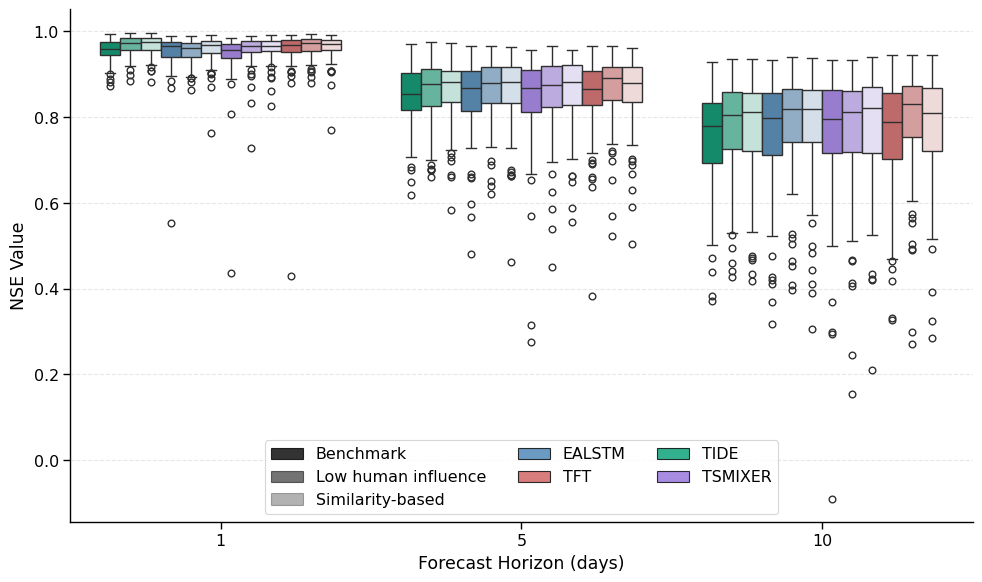

In [24]:
palette = generate_color_triplets(8)

fig, axes = plot_metric_boxplot(
    evaluator_results=seasonal_results,
    model_names=[
        "tide_benchmark",
        "tide_hii",
        "tide_similarity",
        "ealstm_benchmark",
        "ealstm_hii",
        "ealstm_similarity",
        "tsmixer_benchmark",
        "tsmixer_hii",
        "tsmixer_similarity",
        "tft_benchmark",
        "tft_hii",
        "tft_similarity",
    ],
    scenario_mapping={
        "hii": "Low human influence",
        "similarity": "Similarity-based",
        "benchmark": "Benchmark",
    },
    metric="NSE",
    horizons=[1, 5, 10],
    palette=color_triplets,
    num_variations=3,
)

path_to_save = f"/Users/cooper/Desktop/CAMELS-CH/images/DataSharing/global_boxplots_all_models_{COUNTRY}.png"
fig.savefig(path_to_save, dpi=300, bbox_inches="tight")

plt.show()


In [25]:
def plot_model_cdf_grid(
    seasonal_results: Dict,
    model_names: List[str],
    scenario_mapping: Dict[str, str] = None,
    horizons: List[int] = [1, 5, 10],
    palette: List[str] = None,
    num_variations: int = 3,
    fig_size: Tuple[int, int] = (10, 7),
) -> Tuple[plt.Figure, List[plt.Axes]]:
    """
    Plot a grid of CDF curves for different models and prediction horizons with
    standardized x-axis limits per horizon.

    Args:
        seasonal_results: Dictionary containing model evaluation results by basin and horizon
        model_names: List of model names to include in the plot (format: "model_scenario")
        scenario_mapping: Dictionary mapping scenario suffixes to display names
                         (e.g., {"benchmark": "Benchmark", "hii": "Low human influence"})
        horizons: List of forecast horizons to include
        palette: Color palette for different models and their variations
        num_variations: Number of variations for each model (scenarios)
        fig_size: Figure dimensions as (width, height)

    Returns:
        Tuple containing the figure and list of axes
    """
    # Extract unique base models from model names
    base_models = set()
    scenarios = set()

    for model_name in model_names:
        parts = model_name.split("_")
        if len(parts) > 1:
            base_models.add(parts[0])
            scenarios.add(parts[1])

    # Sort base models and scenarios for consistent ordering
    base_models = sorted(list(base_models))
    scenarios = sorted(list(scenarios))

    # If no scenario mapping is provided, create a default one
    if scenario_mapping is None:
        scenario_mapping = {
            scenario: scenario.replace("_", " ").title() for scenario in scenarios
        }

    # Define x-axis limits for each horizon row
    horizon_xlims = {
        1: (0.8, 1.0),  # 1-day horizon: 0.8 to 1.0
        5: (0.4, 1.0),  # 5-day horizon: 0.4 to 1.0
        10: (-0.2, 1.0),  # 10-day horizon: -0.2 to 1.0
    }

    # Create color mapping between model names and colors
    color_map = {}
    base_model_to_color_index = {}

    # Associate each base model with a color index in the palette
    for i, base_model in enumerate(base_models):
        base_model_to_color_index[base_model] = i

    # Map each model_name to its appropriate color from the palette
    for model_name in model_names:
        parts = model_name.split("_")
        if len(parts) > 1:
            base_model = parts[0]
            scenario = parts[1]

            # Get the base color index for this model
            base_idx = base_model_to_color_index[base_model]

            # Determine the scenario index
            scenario_idx = scenarios.index(scenario)

            # Calculate the palette index
            palette_idx = (base_idx * num_variations) + scenario_idx

            # Assign the color from the palette
            if palette and palette_idx < len(palette):
                color_map[model_name] = palette[palette_idx]

    # Create figure and subplots
    fig, axes = plt.subplots(len(horizons), len(base_models), figsize=fig_size)

    # Handle case where there's only one horizon or one model
    if len(horizons) == 1 and len(base_models) == 1:
        axes = np.array([[axes]])
    elif len(horizons) == 1:
        axes = axes.reshape(1, -1)
    elif len(base_models) == 1:
        axes = axes.reshape(-1, 1)

    # Loop through each row (horizon)
    for i, horizon in enumerate(horizons):
        # Loop through each column (base model)
        for j, base_model in enumerate(base_models):
            ax = axes[i, j]

            # For each scenario of this base model
            for scenario in scenarios:
                model_key = f"{base_model}_{scenario}"

                # Skip if this model_scenario combination doesn't exist
                if model_key not in model_names:
                    continue

                # Extract NSE values for the specific horizon
                nse_values = []

                # Get the values
                if model_key in seasonal_results:
                    for basin, metrics in seasonal_results[model_key][
                        "basin_metrics"
                    ].items():
                        if horizon in metrics and "NSE" in metrics[horizon]:
                            val = metrics[horizon]["NSE"]
                            # Convert numpy float32 to Python float if needed
                            if hasattr(val, "item"):
                                val = val.item()
                            # Only add non-NaN values
                            if not np.isnan(val):
                                nse_values.append(val)

                # Plot CDF if we have data
                if nse_values:
                    # Sort values for CDF
                    nse_values.sort()

                    # Calculate cumulative probabilities
                    prob = np.arange(1, len(nse_values) + 1) / len(nse_values)

                    # Plot CDF curve
                    ax.plot(
                        nse_values,
                        prob,
                        label=scenario_mapping.get(scenario, scenario),
                        color=color_map.get(model_key, "black"),
                        linewidth=1.8,
                    )

                    # Calculate and plot median
                    median_val = np.median(nse_values)
                    ax.axvline(
                        x=median_val,
                        color=color_map.get(model_key, "black"),
                        linestyle="--",
                        linewidth=1.5,
                    )

            # Set standardized x-axis limits based on horizon
            if horizon in horizon_xlims:
                ax.set_xlim(horizon_xlims[horizon])

            # Ensure 1.0 is included in the x-ticks
            current_ticks = list(ax.get_xticks())
            if 1.0 not in current_ticks:
                current_ticks.append(1.0)
                ax.set_xticks(sorted(current_ticks))

            # Add titles and labels
            if i == 0:
                ax.set_title(base_model.upper(), fontsize=14)
            if j == 0:
                ax.set_ylabel(f"{horizon} Day - CDF", fontsize=12)
            if i == len(horizons) - 1:
                ax.set_xlabel("NSE", fontsize=12)

            # Add grid
            ax.grid(True, alpha=0.3, linestyle="--")

            # Set y-axis to show values from 0 to 1
            ax.set_ylim(0, 1)

    # Create a legend with all scenarios in black with varying alpha
    handles = []

    # Add each scenario with decreasing alpha
    for i, scenario in enumerate(scenarios):
        # Calculate alpha for this scenario (starting at 1.0, decreasing by 0.2)
        alpha = max(0.3, 1.0 - (i * 0.4))

        # Add line to legend
        handles.append(plt.Line2D([0], [0], color="black", linewidth=1.8, alpha=alpha))

    # Add median line
    handles.append(plt.Line2D([0], [0], color="black", linewidth=1.5, linestyle="--"))

    # Create labels from scenario mapping
    labels = [scenario_mapping.get(scenario, scenario) for scenario in scenarios]
    labels.append("Median value")

    # Add legend
    fig.legend(
        handles=handles,
        labels=labels,
        loc="lower center",
        ncol=len(scenarios) + 1,  # +1 for the median line
        bbox_to_anchor=(0.5, 0.01),
        fontsize=12,
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    sns.despine()

    return fig, axes

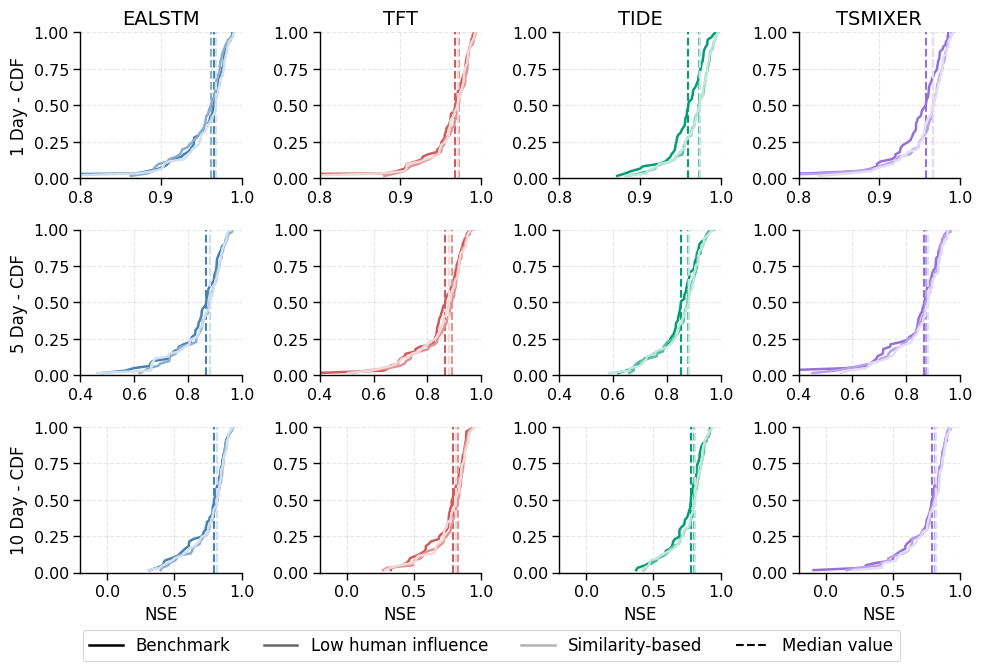

In [26]:
scenario_mapping = {
    "benchmark": "Benchmark",
    "similarity": "Similarity-based",
    "hii": "Low human influence",
}

# Call refactored function
fig, axes = plot_model_cdf_grid(
    seasonal_results=seasonal_results,
    model_names=[
        "tide_benchmark",
        "tide_similarity",
        "tide_hii",
        "ealstm_benchmark",
        "ealstm_similarity",
        "ealstm_hii",
        "tsmixer_benchmark",
        "tsmixer_similarity",
        "tsmixer_hii",
        "tft_benchmark",
        "tft_similarity",
        "tft_hii",
    ],
    scenario_mapping=scenario_mapping,
    horizons=[1, 5, 10],
    palette=color_triplets,
    num_variations=3,
)

# # Save and display plot
path_to_save = f"/Users/cooper/Desktop/CAMELS-CH/images/DataSharing/global_cdf_grid_all_models_{COUNTRY}.png"
plt.savefig(path_to_save, bbox_inches="tight", dpi=300)
plt.show()